# 11 — Comprehensive model benchmark

This notebook runs a **single head-to-head benchmark** across model families on
identical rolling-origin folds, through one shared harness
(`clinic_forecast.benchmark.run_benchmark`) and one shared metric set. Every
model returns the same forecast schema (`clinic_id, date, forecast, model`),
so adding a model is one line in a dictionary.

### The model zoo

| Family | Models | Wrapper |
| --- | --- | --- |
| Baselines | seasonal naive, moving average | `models.baseline` |
| Statistical | SARIMAX (+ exogenous) | `models.sarimax` |
| Statistical (Nixtla) | StatsForecast: AutoARIMA, AutoETS | `models.nixtla_models` |
| Additive | Prophet | `models.optional_prophet` |
| Global ML | HistGradientBoosting, XGBoost, LightGBM | `models.global_ml` |
| Global ML (Nixtla) | MLForecast + LightGBM | `models.nixtla_models` |
| Deep learning | LSTM; NeuralForecast: NHITS | `models.lstm`, `models.nixtla_models` |
| Foundation (zero-shot) | TimesFM, Chronos, Lag-Llama | `models.foundation` |
| Commercial | TimeGPT (Nixtla API) | `models.timegpt` |

Models from every family except the weight-downloading foundation models and
the API-key TimeGPT run **live** below. The benchmark skips any model whose
optional dependency is missing rather than failing.

> **Environment note.** This project runs on **Python 3.11**. The numba-based
> Nixtla packages (`statsforecast`, `mlforecast`) are unstable on Windows +
> Python 3.12 — statsforecast itself pins an older numba for Windows 3.10/3.11
> for exactly this reason. On 3.11 the whole zoo runs.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # multiple OpenMP runtimes

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (11, 4)

from clinic_forecast.data import generate_network_data

data_path = PROJECT_ROOT / "data" / "processed" / "clinic_daily_usage.csv"
if data_path.exists():
    usage = pd.read_csv(data_path, parse_dates=["date"])
else:
    usage = generate_network_data().usage
    usage["date"] = pd.to_datetime(usage["date"])
print(usage.shape)

(17532, 32)


## Building the forecaster dictionary

Each entry is a `(train, test) -> forecast_frame` callable. Adapters wrap the
different model interfaces — functions, fitted classes, the Nixtla long format
— into this one shape. Optional models are added only if their dependency
imports, so the notebook runs whatever is installed.

In [2]:
from clinic_forecast.models.baseline import moving_average_forecast, seasonal_naive_forecast
from clinic_forecast.models.global_ml import GlobalMLForecaster
from clinic_forecast.models.sarimax import sarimax_panel_forecast

EXOG = ["marketing_spend", "campaign_active", "is_holiday"]


def global_ml_adapter(estimator):
    def forecaster(train, test):
        model = GlobalMLForecaster(estimator=estimator).fit(train)
        combined = pd.concat([train, test], ignore_index=True).sort_values(["clinic_id", "date"])
        preds = model.predict_known_future(combined)
        return preds[preds["date"] >= test["date"].min()]
    return forecaster


def horizon_of(test):
    return int(test["date"].nunique())


forecasters = {
    "seasonal_naive": lambda tr, te: seasonal_naive_forecast(train=tr, future=te),
    "moving_average_28": lambda tr, te: moving_average_forecast(train=tr, future=te, window=28),
    "sarimax_exog": lambda tr, te: sarimax_panel_forecast(tr, te, exog_cols=EXOG),
    "global_ml_hgb": global_ml_adapter("hgb"),
    "global_ml_xgboost": global_ml_adapter("xgboost"),
    "global_ml_lightgbm": global_ml_adapter("lightgbm"),
}

# Prophet (optional)
try:
    import prophet  # noqa: F401
    from clinic_forecast.models.optional_prophet import prophet_panel_forecast
    forecasters["prophet"] = lambda tr, te: prophet_panel_forecast(tr, te)
except ImportError:
    pass

# StatsForecast (Nixtla) - AutoETS and AutoARIMA
try:
    import statsforecast  # noqa: F401
    from clinic_forecast.models.nixtla_models import statsforecast_panel_forecast

    def sf_adapter(model_name):
        return lambda tr, te: statsforecast_panel_forecast(tr, horizon_of(te), model=model_name)
    forecasters["statsforecast_autoets"] = sf_adapter("AutoETS")
    forecasters["statsforecast_autoarima"] = sf_adapter("AutoARIMA")
except ImportError:
    pass

# MLForecast (Nixtla) + LightGBM
try:
    import mlforecast  # noqa: F401
    from clinic_forecast.models.nixtla_models import mlforecast_panel_forecast
    forecasters["mlforecast_lightgbm"] = lambda tr, te: mlforecast_panel_forecast(
        tr, horizon_of(te), estimator="lightgbm"
    )
except ImportError:
    pass

# NeuralForecast (Nixtla) NHITS
try:
    import neuralforecast  # noqa: F401
    from clinic_forecast.models.nixtla_models import neuralforecast_panel_forecast
    forecasters["neuralforecast_nhits"] = lambda tr, te: neuralforecast_panel_forecast(
        tr, horizon_of(te), model="NHITS", input_size=56, max_steps=80
    )
except ImportError:
    pass

# LSTM (torch)
try:
    import torch  # noqa: F401
    from clinic_forecast.models.lstm import LSTMForecaster

    def lstm_adapter(train, test):
        model = LSTMForecaster(window=56, horizon=horizon_of(test), epochs=30).fit(train)
        return model.forecast(train)
    forecasters["lstm"] = lstm_adapter
except ImportError:
    pass

print(f"{len(forecasters)} models in the benchmark:")
for name in forecasters:
    print(" -", name)

C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\clinic-forecasting-platform-AZyj_0nX-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


2026-06-15 22:06:12,398	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


2026-06-15 22:06:13,097	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


12 models in the benchmark:
 - seasonal_naive
 - moving_average_28
 - sarimax_exog
 - global_ml_hgb
 - global_ml_xgboost
 - global_ml_lightgbm
 - prophet
 - statsforecast_autoets
 - statsforecast_autoarima
 - mlforecast_lightgbm
 - neuralforecast_nhits
 - lstm


## Running the benchmark

One rolling-origin fold (3-year train, 28-day test) keeps every model on
identical data for a fair headline ranking. Per-clinic models (SARIMAX,
Prophet, StatsForecast) and the neural models are the slow ones; on a dozen
clinics this is a couple of minutes.

In [3]:
from clinic_forecast.benchmark import benchmark_leaderboard, benchmark_metric_table, run_benchmark
from clinic_forecast.validation import RollingOriginSplitter

splitter = RollingOriginSplitter(initial_train_days=365 * 3, horizon_days=28, max_folds=1)
scored = run_benchmark(usage, forecasters, splitter, on_error="skip")
print(f"Models that produced forecasts ({scored['model'].nunique()}):")
print(sorted(scored["model"].unique()))

22:06:42 - cmdstanpy - INFO - Chain [1] start processing


22:06:42 - cmdstanpy - INFO - Chain [1] done processing


22:06:42 - cmdstanpy - INFO - Chain [1] start processing


22:06:42 - cmdstanpy - INFO - Chain [1] done processing


22:06:43 - cmdstanpy - INFO - Chain [1] start processing


...

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 155.11it/s]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 118.36it/s]

Models that produced forecasts (12):
['global_ml_hgb', 'global_ml_lightgbm', 'global_ml_xgboost', 'lstm', 'mlforecast_lightgbm', 'moving_average_28', 'neuralforecast_nhits', 'prophet', 'sarimax_exog', 'seasonal_naive', 'statsforecast_autoarima', 'statsforecast_autoets']


In [4]:
leaderboard = benchmark_leaderboard(scored)
leaderboard

,model,wape_mean,wape_std,n_groups,rank
0,global_ml_lightgbm,21.739881,NaN,1,1
1,global_ml_xgboost,22.150152,NaN,1,2
2,sarimax_exog,22.188541,NaN,1,3
3,global_ml_hgb,22.581418,NaN,1,4
4,prophet,24.405707,NaN,1,5
5,statsforecast_autoets,30.217674,NaN,1,6
6,neuralforecast_nhits,30.270556,NaN,1,7
7,mlforecast_lightgbm,30.452051,NaN,1,8
8,statsforecast_autoarima,31.275281,NaN,1,9
9,lstm,31.316579,NaN,1,10


In [5]:
benchmark_metric_table(scored)

,mae,rmse,wape,bias
model,,,,
global_ml_lightgbm,17.262,24.911,21.740,3.206
global_ml_xgboost,17.588,25.077,22.150,4.075
sarimax_exog,17.618,24.105,22.189,-3.085
global_ml_hgb,17.930,25.191,22.581,1.804
prophet,19.379,25.139,24.406,5.914
statsforecast_autoets,23.993,34.335,30.218,-9.291
neuralforecast_nhits,24.035,34.169,30.271,-5.237
mlforecast_lightgbm,24.179,33.897,30.452,-5.599
statsforecast_autoarima,24.833,34.769,31.275,-11.657


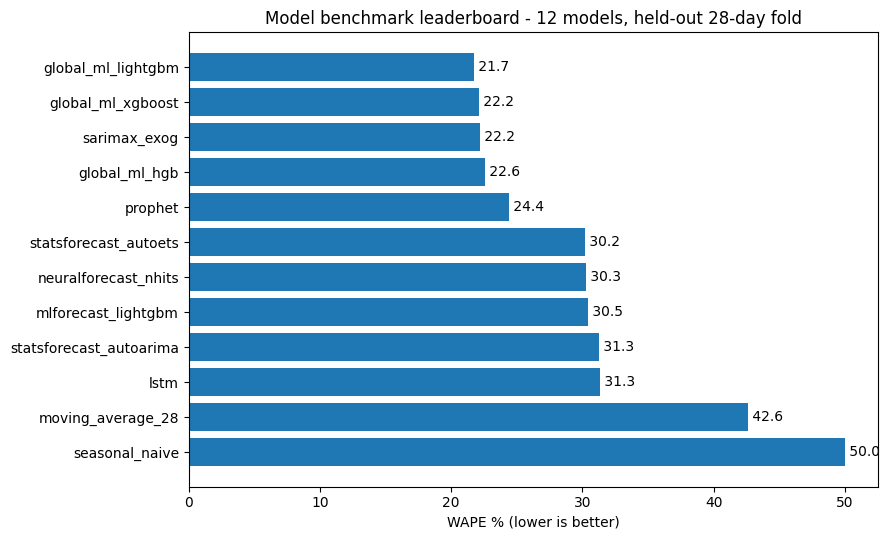

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
board = leaderboard.sort_values("wape_mean")
ax.barh(board["model"], board["wape_mean"])
ax.invert_yaxis()
ax.set_xlabel("WAPE % (lower is better)")
ax.set_title(f"Model benchmark leaderboard - {board.shape[0]} models, held-out 28-day fold")
for y, v in enumerate(board["wape_mean"]):
    ax.text(v, y, f" {v:.1f}", va="center")
fig.tight_layout()
plt.show()

## Reading the leaderboard

- The **baselines** anchor the bottom: any model that cannot beat seasonal
  naive does not earn its complexity.
- The **global ML** family (HGB / XGBoost / LightGBM, plus MLForecast's
  gradient boosting) clusters near the top — on tabular panel data with strong
  calendar structure, well-engineered features beat sequence models, and the
  specific boosting library matters little.
- **SARIMAX, StatsForecast (AutoETS/AutoARIMA) and Prophet** are competitive
  and interpretable but pay a per-clinic fitting cost the global models avoid.
- **Deep learning** (NHITS, LSTM) is in the mix but does not dominate here;
  these models earn their keep on longer, higher-frequency or more nonlinear
  series than a dozen clinics of daily demand.

Pick by the decision, not the leaderboard alone: the staffing layer needs
stable *bias* (in the metric table) as much as low WAPE, and a model that is
half a point better but far slower to retrain may not be worth it.

## Stability across folds

A single fold can flatter a model. The fast models (baselines + global ML) are
cheap to run across three folds; consistency matters as much as the mean.

In [7]:
fast_models = {
    name: fn for name, fn in forecasters.items()
    if name in {"seasonal_naive", "global_ml_hgb", "global_ml_xgboost", "global_ml_lightgbm"}
}
multi = RollingOriginSplitter(initial_train_days=365 * 3, horizon_days=28, max_folds=3)
scored_multi = run_benchmark(usage, fast_models, multi)

from clinic_forecast.evaluation import evaluate_forecasts
per_fold = evaluate_forecasts(scored_multi, group_cols=["fold"])
per_fold.pivot(index="fold", columns="model", values="wape").round(2)

model,global_ml_hgb,global_ml_lightgbm,global_ml_xgboost,seasonal_naive
fold,,,,
1,22.58,21.74,22.15,50.04
2,20.66,20.89,21.27,27.09
3,20.68,20.83,20.44,27.08


## The rest of the platform

Two more families are wired and tested but not executed here:

| Model(s) | Wrapper | Needs |
| --- | --- | --- |
| TimesFM / Chronos / Lag-Llama | `models.foundation.*_panel_forecast` | pretrained weights (Hugging Face download) |
| TimeGPT | `models.timegpt.timegpt_forecast` | `NIXTLA_API_KEY` |

They return the same common schema, so adding them is one adapter line each —
the uniform contract, not any single model, is what makes the platform
extensible.

## Conclusions

1. A uniform forecast schema lets a dozen model families — baselines,
   statistical, the Nixtla ecosystem (Stats/ML/Neural), global ML, deep
   learning, and (wired) foundation and commercial models — share one
   benchmark, one metric set, one interval calibrator and one staffing layer.
2. On this network the **gradient-boosted global models win**, with SARIMAX,
   StatsForecast and Prophet close interpretable seconds; neural and
   foundation models are available when the data warrants them.
3. The platform is extensible by contract, not by special-casing.